## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [11]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [12]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [ ]:
df_baseline = pd.read_csv(f"../../bench_results_copy_{dtype}.csv")
df_baseline["S"] = "copy"
add_stats_siso(df_baseline, 4)


#df_tiled = pd.read_csv(f"../bench_results_mcscan_{dtype}.csv")
#df_tiled["S"] = "PyTorch"
df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.concat(map(pd.read_csv, glob(join('..', '..', f"bench_results_mcscan*_{tile}_{dtype}.csv"))))
    df_tmp["S"] = df_tmp["operator"]
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_baseline, df_tiled])

## Paper plots

/tmp/ipykernel_3887094/3668118024.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


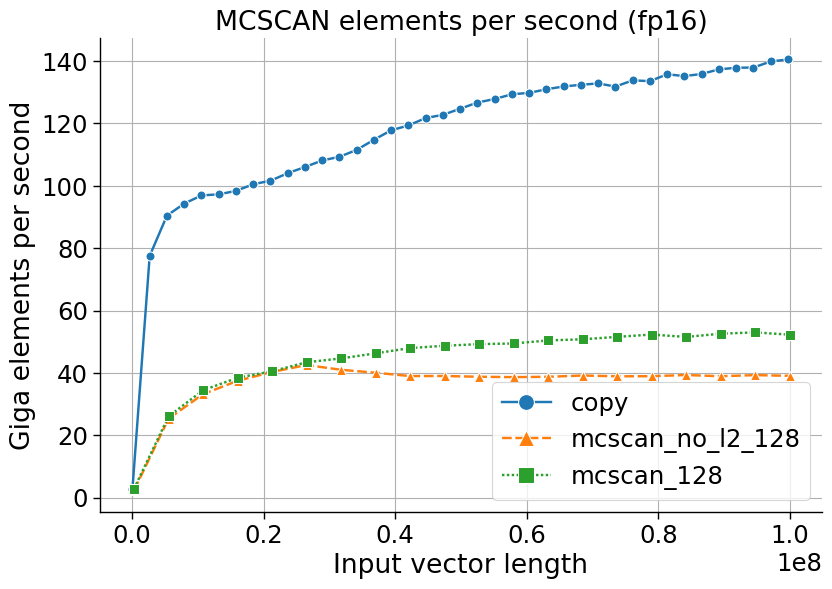

<Figure size 870x627 with 0 Axes>

In [30]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_3887094/302085082.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


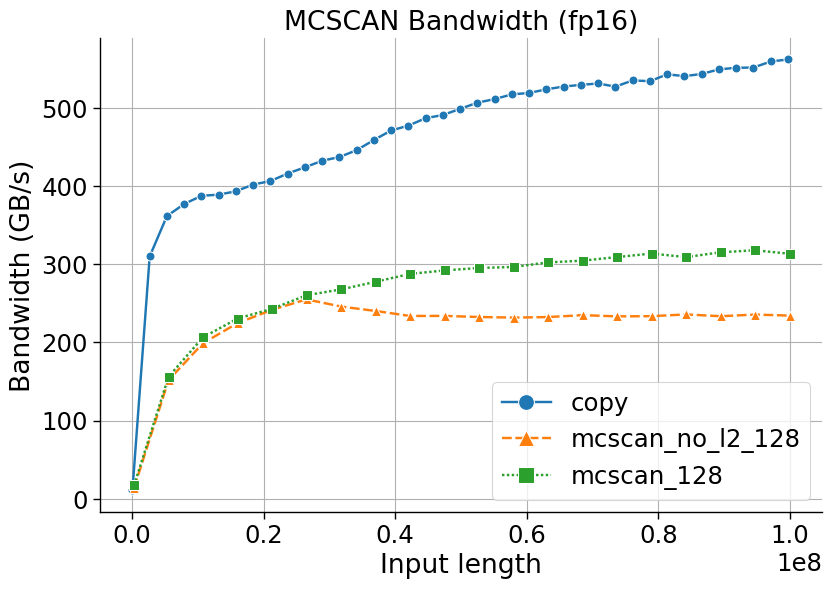

<Figure size 870x627 with 0 Axes>

In [31]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [16]:
df

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy,fp16,81920,NaN,81920,30.67,copy,2,327680,2.671014,10.684056
1,copy,fp16,2703360,NaN,2703360,34.87,copy,2,10813440,77.526814,310.107256
2,copy,fp16,5324800,NaN,5324800,58.87,copy,2,21299200,90.450144,361.800578
3,copy,fp16,7946240,NaN,7946240,84.27,copy,2,31784960,94.295004,377.180017
4,copy,fp16,10567680,NaN,10567680,109.04,copy,2,42270720,96.915627,387.662509
...,...,...,...,...,...,...,...,...,...,...,...
34,mcscan_64,fp16,89210880,NaN,89210880,2473.95,S=128,2,535265280,36.060098,216.360589
35,mcscan_64,fp16,91832320,NaN,91832320,2536.27,S=128,2,550993920,36.207628,217.245766
36,mcscan_64,fp16,94453760,NaN,94453760,2645.20,S=128,2,566722560,35.707606,214.245637
37,mcscan_64,fp16,97075200,NaN,97075200,2703.82,S=128,2,582451200,35.902982,215.417890
